# Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

import pickle

# Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving airbnb_dataset.csv to airbnb_dataset (1).csv


In [ ]:
import io

filename=list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,06-26-08,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,06-26-08,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,07-25-08,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,08-12-08,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,08-15-08,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0


# EDA

In [ ]:
print(f"shape(rows,columns):{df.shape}\n")
print(f"{df.describe()}\n")
print(df.info())

shape(rows,columns):(30475, 13)

            Host Id  Review Scores Rating (bin)       Zipcode          Beds  \
count  3.047500e+04                22155.000000  30341.000000  30390.000000   
mean   1.273040e+07                   90.738659  10584.830691      1.530141   
std    1.190164e+07                    9.059519    921.324686      1.015395   
min    5.000000e+02                   20.000000   1003.000000      0.000000   
25%    2.700193e+06                   85.000000  10017.000000      1.000000   
50%    8.551260e+06                   90.000000  10065.000000      1.000000   
75%    2.119605e+07                  100.000000  11216.000000      2.000000   
max    4.303307e+07                  100.000000  99135.000000     16.000000   

       Number of Records  Number Of Reviews  Review Scores Rating  
count            30475.0       30475.000000          22155.000000  
mean                 1.0          12.019852             91.993230  
std                  0.0          21.981496        

In [ ]:
num_cols=df.select_dtypes(include='number').columns.tolist()
cat_cols=df.select_dtypes(include='object').columns.tolist()

print(f"numerical cols: {num_cols}")
print(f"categorical cols: {cat_cols}")

numerical cols: ['Host Id', 'Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Number of Records', 'Number Of Reviews', 'Review Scores Rating']
categorical cols: ['Host Since', 'Name', 'Neighbourhood ', 'Property Type', 'Room Type', 'Price']


In [ ]:
df['Host Since']=pd.to_datetime(df['Host Since'], format="%m-%d-%y", errors='coerce')
df['Host Since'].head()

,Host Since
0,2008-06-26
1,2008-06-26
2,2008-07-25
3,2008-08-12
4,2008-08-15


## Handle Missing Values

In [ ]:
# Drop columns not useful for ML
df.drop(columns=['Host Id', 'Name', 'Number of Records'], inplace=True)
df.shape

(30475, 10)

In [ ]:
# Fix Price Column (object → numeric)
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(',', ''), errors='coerce')
print(df['Price'].describe())

count    30475.000000
mean       163.598950
std        197.792306
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64


In [ ]:
df.isnull().sum()

,0
Host Since,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8320
Room Type,0
Zipcode,134
Beds,85
Number Of Reviews,0
Price,0
Review Scores Rating,8320


Checking skewness for:  ['Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Number Of Reviews', 'Price', 'Review Scores Rating']


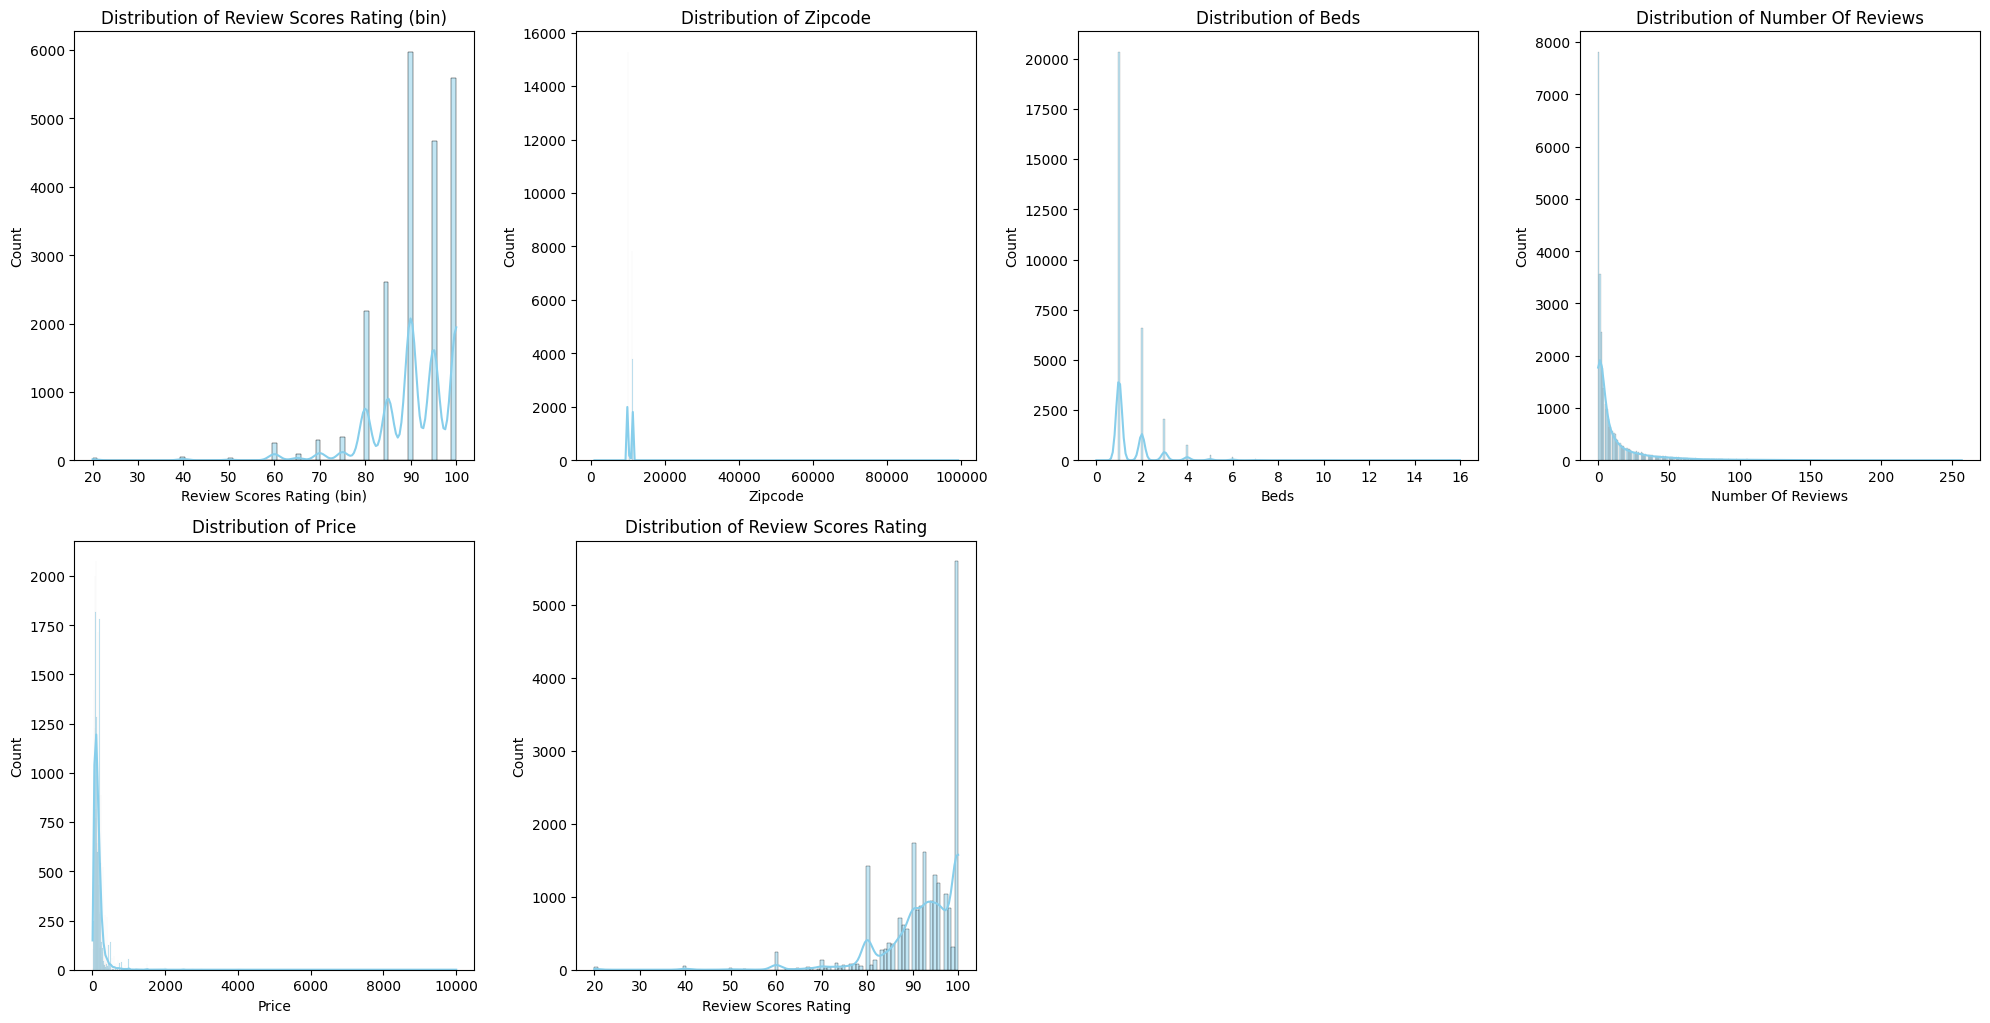

Skewness Table:
Review Scores Rating (bin)    -2.108565
Zipcode                       53.815860
Beds                           3.827279
Number Of Reviews              3.600884
Price                         15.561952
Review Scores Rating          -2.478578
dtype: float64


In [ ]:
# Check skewness
num_cols=df.select_dtypes(include='number').columns.tolist()

print('Checking skewness for: ',num_cols)
plt.figure(figsize=(20,15))
for i,col in enumerate(num_cols):
  plt.subplot(3,4,i+1)
  sns.histplot(df[col].dropna(), kde=True, color='skyblue')
  plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Print Skewness
print("Skewness Table:")
print(df[num_cols].skew())

In [ ]:
# Zipcode -- Not a real numeric feature — just a location code
# Columns that need log transform
log_cols = ['Price', 'Beds', 'Number Of Reviews']

for col in log_cols:
    df[col] = np.log1p(df[col])

print("\n Skewness After Log Transform:")
print(df[log_cols].skew())


 Skewness After Log Transform:
Price                0.611813
Beds                 1.699446
Number Of Reviews    0.435302
dtype: float64


In [ ]:
# Fill missing values
# Here all numerical columns are highly skewed and need to fill it with median

# Fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
  df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
  df[col].fillna(df[col].mode()[0], inplace=True)


print("Missing values after filling:\n", df.isnull().sum())

Missing values after filling:
 Host Since                    0
Neighbourhood                 0
Property Type                 0
Review Scores Rating (bin)    0
Room Type                     0
Zipcode                       0
Beds                          0
Number Of Reviews             0
Price                         0
Review Scores Rating          0
dtype: int64


/tmp/ipykernel_444/2207828854.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_444/2207828854.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

## Feature Engineering

In [ ]:
# Date time features
df['Host Year']          = df['Host Since'].dt.year
df['Host Month']         = df['Host Since'].dt.month
df['Host_days_active']   = (pd.Timestamp.today() - df['Host Since']).dt.days

# Experience Level — 4 balanced groups
df['Host_experience_level'] = pd.qcut(df['Host_days_active'],
                                       q=4,
                                       labels=[1, 2, 3, 4])  # numeric directly

# Interaction Feature — how active is the listing
df['reviews_per_day'] = df['Number Of Reviews'] / (df['Host_days_active'] + 1)

print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (30475, 15)
Host Since                    datetime64[ns]
Neighbourhood                         object
Property Type                         object
Review Scores Rating (bin)           float64
Room Type                             object
Zipcode                              float64
Beds                                 float64
Number Of Reviews                    float64
Price                                float64
Review Scores Rating                 float64
Host Year                              int32
Host Month                             int32
Host_days_active                       int64
Host_experience_level               category
reviews_per_day                      float64
dtype: object


In [ ]:
# Drop Host Since — extracted everything needed
df.drop(columns=['Host Since'], inplace=True)

# Convert Host_experience_level category → int
df['Host_experience_level'] = df['Host_experience_level'].astype(int)

In [ ]:
cat_cols=df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(col, df[col].unique())


Neighbourhood  ['Manhattan' 'Brooklyn' 'Queens' 'Bronx' 'Staten Island']
Property Type ['Apartment' 'House' 'Other' 'Bed & Breakfast' 'Loft' 'Condominium'
 'Townhouse' 'Dorm' 'Boat' 'Cabin' 'Villa' 'Bungalow' 'Camper/RV'
 'Treehouse' 'Tent' 'Hut' 'Lighthouse' 'Chalet' 'Castle']
Room Type ['Entire home/apt' 'Private room' 'Shared room']


# Encoding

In [ ]:
# Remove trailing spaces from all columns
df.columns = df.columns.str.strip()
print(df.columns.tolist())

# Label Encode
le = LabelEncoder()
for col in ['Neighbourhood', 'Property Type']:
    df[col] = le.fit_transform(df[col].astype(str))


# Ordinal Encode — Room Type
room_type_order = {
    'Shared room'    : 0,
    'Private room'   : 1,
    'Entire home/apt': 2
}
df['Room Type'] = df['Room Type'].map(room_type_order)


['Neighbourhood', 'Property Type', 'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds', 'Number Of Reviews', 'Price', 'Review Scores Rating', 'Host Year', 'Host Month', 'Host_days_active', 'Host_experience_level', 'reviews_per_day']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Neighbourhood               30475 non-null  int64  
 1   Property Type               30475 non-null  int64  
 2   Review Scores Rating (bin)  30475 non-null  float64
 3   Room Type                   30475 non-null  int64  
 4   Zipcode                     30475 non-null  float64
 5   Beds                        30475 non-null  float64
 6   Number Of Reviews           30475 non-null  float64
 7   Price                       30475 non-null  float64
 8   Review Scores Rating        30475 non-null  float64
 9   Host Year                   30475 non-null  int32  
 10  Host Month                  30475 non-null  int32  
 11  Host_days_active            30475 non-null  int64  
 12  Host_experience_level       30475 non-null  int64  
 13  reviews_per_day             304

Price                         1.000000
Room Type                     0.636769
Beds                          0.425196
Zipcode                      -0.223427
Neighbourhood                 0.130945
Review Scores Rating          0.094827
Review Scores Rating (bin)    0.086595
Host_experience_level         0.084384
Host_days_active              0.083731
Host Year                    -0.081713
Property Type                -0.040339
reviews_per_day              -0.016144
Number Of Reviews            -0.006251
Host Month                   -0.000541
Name: Price, dtype: float64


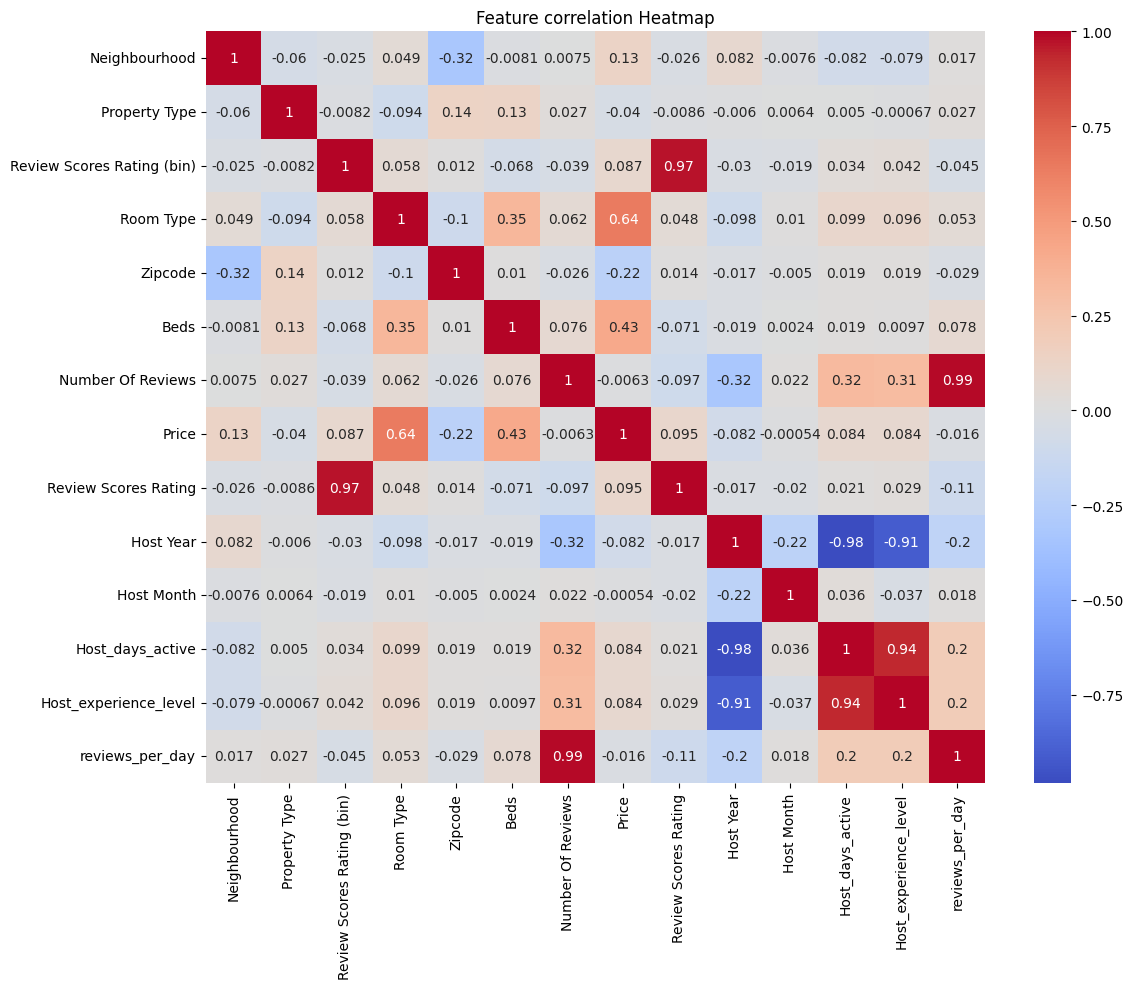

In [ ]:
df_copy = df.copy()
corr = df_copy.corr(numeric_only=True)['Price']
print(corr.sort_values(key=abs, ascending=False))

plt.figure(figsize=(12,10))
sns.heatmap(df_copy.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Feature correlation Heatmap')
plt.tight_layout()
plt.show()

## VIF(Variance Inflation Factor) Check

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=['Price'])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_data)

                       Feature          VIF
0         Review Scores Rating  3287.003592
1   Review Scores Rating (bin)  3013.963201
2                    Host Year   886.990281
3             Host_days_active   842.430061
4            Number Of Reviews   225.984937
5              reviews_per_day   218.604022
6                      Zipcode   152.205366
7        Host_experience_level    52.293758
8                         Beds    11.614936
9                    Room Type    10.410272
10               Neighbourhood     8.679722
11                  Host Month     5.386581
12               Property Type     1.177117


In [ ]:
# Drop only the REDUNDANT ones — keep best from each group
drop_cols = ['Review Scores Rating (bin)',  # redundant with Review Scores Rating
             'Host Year',                   # redundant with Host_days_active
             'Number Of Reviews',           # redundant with reviews_per_day
             'Zipcode']                     # redundant with Neighbourhood

df.drop(columns=drop_cols, inplace=True)

print(f" Shape: {df.shape}")
print(f"Remaining: {df.columns.tolist()}")

 Shape: (30475, 10)
Remaining: ['Neighbourhood', 'Property Type', 'Room Type', 'Beds', 'Price', 'Review Scores Rating', 'Host Month', 'Host_days_active', 'Host_experience_level', 'reviews_per_day']


# Split Features and Target

In [ ]:
X = df.drop(columns='Price')
y = df['Price']

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature shape: (30475, 9)
Target shape: (30475,)


# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (24380, 9)
X_test shape: (6095, 9)
y_train shape: (24380,)
y_test shape: (6095,)


# Model Selection using Pipeline

In [ ]:
pipelines = {
    'Linear Regression': Pipeline([
        ('scaler' , StandardScaler()),
        ('model' , LinearRegression())
      ]),

    'Decision Tree' : Pipeline([
        ('scaler' , StandardScaler()),
        ('model' , DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ))
    ]),

    'Random Forest' : Pipeline([
        ('scaler' , StandardScaler()),
        ('model' , RandomForestRegressor(
            n_estimators=200,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'XGBoost' : Pipeline([
        ('scaler' , StandardScaler()),
        ('model' , XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

results = {}

for name,pipeline in pipelines.items():
  pipeline.fit(X_train, y_train)
  y_pred = pipeline.predict(X_test)

  results[name] = {
        'MAE' : mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2'  : r2_score(y_test, y_pred)
    }

  print(f"{name:20}  MAE={results[name]['MAE']:.4f}  RMSE={results[name]['RMSE']:.4f}  R2={results[name]['R2']:.4f}")

Linear Regression     MAE=0.3341  RMSE=0.4476  R2=0.4835
Decision Tree         MAE=0.3087  RMSE=0.4167  R2=0.5522
Random Forest         MAE=0.3220  RMSE=0.4298  R2=0.5237
XGBoost               MAE=0.2955  RMSE=0.3931  R2=0.6016


## Hyperparameter Tuning on Best Model ( XGBoost )

In [ ]:
param_grid = {
    'model__n_estimators'    : [200, 300, 400],
    'model__max_depth'       : [3, 4, 5],
    'model__learning_rate'   : [0.01, 0.05, 0.1],
    'model__subsample'       : [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  XGBRegressor(random_state=42, n_jobs=-1))
])

search = RandomizedSearchCV(xgb_pipeline, param_grid,
                            n_iter=20, cv=5, scoring='r2',
                            random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

# Results
y_pred_tuned = search.predict(X_test)
print(f"Best Params : {search.best_params_}")
print(f"CV R2       : {search.best_score_:.4f}")
print(f"Test R2     : {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Test MAE    : {mean_absolute_error(y_test, y_pred_tuned):.4f}")
print(f"Test RMSE   : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}")

# Before vs After
print(f"\nBefore → R2={results['XGBoost']['R2']:.4f} MAE={results['XGBoost']['MAE']:.4f}")
print(f"After  → R2={r2_score(y_test, y_pred_tuned):.4f} MAE={mean_absolute_error(y_test, y_pred_tuned):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params : {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
CV R2       : 0.5859
Test R2     : 0.6038
Test MAE    : 0.2947
Test RMSE   : 0.3920

Before → R2=0.6016 MAE=0.2955
After  → R2=0.6038 MAE=0.2947


# Cross Validate Best Model

In [ ]:
# Cross Validation
cv_scores = cross_val_score(
                pipelines['XGBoost'],
                X_train,
                y_train,
                cv     = 5,
                scoring= 'r2',
                n_jobs = -1
)

# Detailed Summary
print("=" * 45)
print("      CROSS VALIDATION SUMMARY")
print("=" * 45)
print(f"  Fold 1  :  {cv_scores[0]:.4f}")
print(f"  Fold 2  :  {cv_scores[1]:.4f}")
print(f"  Fold 3  :  {cv_scores[2]:.4f}")
print(f"  Fold 4  :  {cv_scores[3]:.4f}")
print(f"  Fold 5  :  {cv_scores[4]:.4f}")
print("-" * 45)
print(f"  Mean CV R2 :  {cv_scores.mean():.4f}")
print(f"  Std R2  :  {cv_scores.std():.4f}")
print(f"  Min R2  :  {cv_scores.min():.4f}")
print(f"  Max R2  :  {cv_scores.max():.4f}")
print("-" * 45)
print(f"  Test R2 :  {results['XGBoost']['R2']:.4f}")
print(f"  Test MAE:  {results['XGBoost']['MAE']:.4f}")
print(f"  Test RMSE: {results['XGBoost']['RMSE']:.4f}")
print("=" * 45)

# Stability Check
if cv_scores.std() < 0.05:
    print("Model is STABLE — low variance across folds")
else:
    print("Model is UNSTABLE — high variance across folds")

# CV vs Test Check
diff = abs(cv_scores.mean() - results['XGBoost']['R2'])
if diff < 0.05:
    print("NO Overfitting — CV and Test R2 are close")
else:
    print("Possible Overfitting — CV and Test R2 differ")

      CROSS VALIDATION SUMMARY
  Fold 1  :  0.5732
  Fold 2  :  0.5972
  Fold 3  :  0.5794
  Fold 4  :  0.5742
  Fold 5  :  0.5952
---------------------------------------------
  Mean CV R2 :  0.5838
  Std R2  :  0.0103
  Min R2  :  0.5732
  Max R2  :  0.5972
---------------------------------------------
  Test R2 :  0.6016
  Test MAE:  0.2955
  Test RMSE: 0.3931
Model is STABLE — low variance across folds
NO Overfitting — CV and Test R2 are close


## Pickle file

In [ ]:
# Best model is XGBoost from pipelines dict
best_model = pipelines['XGBoost']

with open('airbnb_xgboost_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(" Model saved as airbnb_xgboost_model.pkl")

 Model saved as airbnb_xgboost_model.pkl
